In [1]:
from tensorflow.keras.preprocessing.text import Tokenizer

text = ["단어 아무거나 입력하세요", "오늘은 비가 옵니다"]

tokenizer = Tokenizer(oov_token="<UNK>")
tokenizer.fit_on_texts(text)

voca_size = len(tokenizer.word_index) + 1

print(tokenizer.word_index)
print(voca_size)

{'<UNK>': 1, '단어': 2, '아무거나': 3, '입력하세요': 4, '오늘은': 5, '비가': 6, '옵니다': 7}
8


In [2]:
# 단어사전을 이용해서 문자를 숫자로 변경

new_text = ["단어 아무거나 입력하세요", "비가 옵니다", "흐립니다."]
new_text_seq = tokenizer.texts_to_sequences(new_text)
new_text_seq


[[2, 3, 4], [6, 7], [1]]

In [3]:
# 3. 단어 숫자 값의 길이를 맞춤 (pad)
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 전체길이를 4로 맞추고 뒤쪽에 0으로 채움
new_text_pad = pad_sequences(new_text_seq, maxlen=4, padding="post")
new_text_pad

array([[2, 3, 4, 0],
       [6, 7, 0, 0],
       [1, 0, 0, 0]], dtype=int32)

In [4]:
# RNN
# (n, 4) => (n, timesteps, feadure_dim)
# (n, 4, 1)
new_text_pad.shape

(3, 4)

In [5]:
# 4. 임베딩 => 토큰을 밀집 벡터로 변환하기 => 랜덤값인데 학습하면 비슷한 단어가 가까워짐

import tensorflow as tf
from tensorflow.keras.layers import Embedding, Input

inputs = Input(shape=(4,))
embedding_output = Embedding(input_dim=voca_size, output_dim=10)(inputs)
model = tf.keras.Model(inputs=inputs, outputs=embedding_output)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 4, 10)          │            80 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80 (320.00 B)

 Trainable params: 80 (320.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
embedding_result = model.predict(new_text_pad)
print(embedding_result.shape)
embedding_result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
(3, 4, 10)


array([[[-0.03152132,  0.0234752 ,  0.00144106,  0.00833273,
         -0.01911999,  0.0458301 , -0.04129058,  0.03278151,
         -0.00599054,  0.00634153],
        [ 0.0328833 , -0.008784  ,  0.01354749,  0.00663345,
          0.04137215, -0.02239425,  0.02851589, -0.03615315,
          0.00814422,  0.00399805],
        [ 0.01395178, -0.00620891,  0.02731903, -0.00658166,
          0.03005547, -0.04961846, -0.0135837 ,  0.03015772,
         -0.00320677, -0.01848163],
        [ 0.04364621, -0.02653619,  0.00106336, -0.00202926,
         -0.03036288, -0.04846472,  0.01285913,  0.019202  ,
          0.00497074, -0.01186074]],

       [[ 0.03697857, -0.00681082, -0.03989964, -0.01385767,
         -0.01121453,  0.0220163 ,  0.04285515,  0.00039325,
         -0.02514645, -0.04851862],
        [-0.04837808, -0.02264646,  0.0424112 , -0.00801414,
         -0.00819342,  0.0024191 ,  0.0482639 , -0.00152165,
          0.0060761 , -0.04519674],
        [ 0.04364621, -0.02653619,  0.00106336, -0

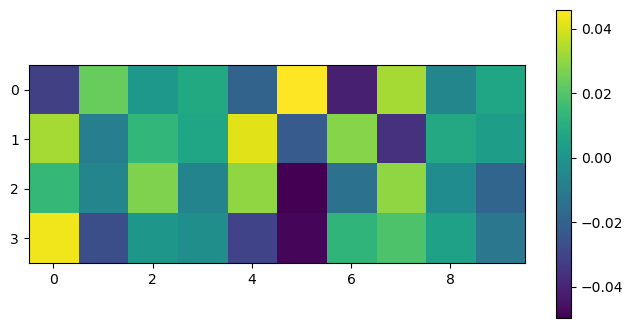

In [7]:
import matplotlib.pyplot as plt

sample = embedding_result[0]

plt.figure(figsize=(8, 4))
plt.imshow(sample)
plt.colorbar()
plt.show()

In [ ]:
# 감정분석 => 영화리뷰를 읽어서 긍정/부정인지 판별
import pandas as pd
train = pd.read_csv("http://114.207.245.181:13000/txt/ratings_train.txt", sep="\t")
test = pd.read_csv("http://114.207.245.181:13000/txt/ratings_test.txt", sep="\t")

train.tail(3)

,id,document,label
149997,9311800,이게 뭐요? 한국인은 거들먹거리고 필리핀 혼혈은 착하다?,0
149998,2376369,청춘 영화의 최고봉.방황과 우울했던 날들의 자화상,1
149999,9619869,한국 영화 최초로 수간하는 내용이 담긴 영화,0


In [3]:
test.tail(3)

,id,document,label
49997,9072549,그림도 좋고 완성도도 높았지만... 보는 내내 불안하게 만든다,0
49998,5802125,절대 봐서는 안 될 영화.. 재미도 없고 기분만 잡치고.. 한 세트장에서 다 해먹네,0
49999,6070594,마무리는 또 왜이래,0


In [4]:
import random
from itertools import islice

# na인것은 삭제
train_clean = train.dropna()
test_clean = test.dropna()

train_texts = train_clean['document'].to_list()
test_texts = test_clean['document'].to_list()

train_labels = train_clean['label'].to_list()
test_labels = test_clean['label'].to_list()

s = random.randint(0, len(train_texts) - 10)
for t,l in islice(zip(train_texts, train_labels), s, s + 10):
    print(f'긍정:{l}' if l == 1 else f'부정:{l}', t)

부정:0 반전만 좋으면 영화가 구제되는가? 난 아니라고 본다..
긍정:1 언 20년 지나서도 다시보고싶다는 생각이든 영화....
긍정:1 내가 진짜 좋아하고 재밌게 봤던 책이 영화로 나온다고 해서 신기했는데 내가제일좋아하는 하정우라는 배우가 감독을 맡고 주연을 한다는 소식이 더 신기했다 영화도역시 너무좋았다.
긍정:1 나는 당연히 좋아할 수 밖에.
부정:0 재미없다.
부정:0 후반기교육가서 봤는데 정말.. 할말이없다... 난 영화관에서 봐서 어쩔수없이 끝까지 봤지만 다운받아서 보는애들은 10분이면 휴지통에 들어가 있을 영화다. 그러니 지금 다운받으려고 고민하면서 평점보고 있는 애들은 조용히 닫기를 눌러 다른영화를 찾아
긍정:1 이건 이상인이 주인공아니야? 박용우는 나왔었나? 전혀 몰랐네~
부정:0 이게 뭐지??...영화맞음??
부정:0 정말 엉성한 스토니에 그래픽이 아깝당...엔딩 결말도 엉성하고....완전 삼류 엉성한 스토리~~
긍정:1 짱!


In [5]:
def clean_texts(texts, labels):
    new_texts = []
    new_labels = []
    for t, l in zip(texts, labels):
        # text값이 비어있지 않고 공백을 제거했을때 최소 1자 이상인 것만 보관
        if t is not None and len(t.strip()) > 0:
            new_texts.append(t)
            new_labels.append(l)
    return new_texts, new_labels

train_texts1, train_labels1 = clean_texts(train_texts, train_labels)
test_texts1, test_labels1 = clean_texts(test_texts, test_labels)

In [6]:
print(len(train_texts1), len(train_labels))
print(len(test_texts1), len(test_labels))

149995 149995
49997 49997


In [16]:
import numpy as np
y_train = np.array(train_labels)
y_test = np.array(test_labels)

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer

voca_size = 20000
tokenizer = Tokenizer(num_words= voca_size, oov_token="<UNK>")
tokenizer.fit_on_texts(train_texts1)

In [8]:
x_train = tokenizer.texts_to_sequences(train_texts)
x_test = tokenizer.texts_to_sequences(test_texts)
x_train[:3]

[[24, 937, 5, 6728, 1098], [603, 6118, 1, 1, 7053, 1], [1]]

In [11]:
# 3. 단어 숫자 값의 길이를 맞춤 (pad)
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

x_train_pad1 = pad_sequences(x_train, maxlen=100, padding="post")
x_test_pad1 = pad_sequences(x_test, maxlen=100, padding="post")

x_train_pad = np.array(x_train_pad1)
x_test_pad = np.array(x_test_pad1)

x_train_pad.shape, x_test_pad.shape

((149995, 100), (49997, 100))

In [18]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Sequential

model = Sequential([
    Input(shape=(100,)),
     # mask_zero=True => 0의 값은 패딩으로처리
    Embedding(input_dim=voca_size, output_dim=128, mask_zero=True),
    LSTM(units=64, activation="tanh"),
    Dense(units=32, activation="relu"),
    Dense(units=1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,521 (9.96 MB)

 Trainable params: 2,611,521 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

4688/4688 - 247s - 53ms/step - accuracy: 0.7961 - loss: 0.4130 - val_accuracy: 0.8139 - val_loss: 0.3819


In [ ]:
model.fit(
    x_train_pad, y_train, validation_data=(x_test_pad, y_test), epochs=10, verbose=2
)

In [23]:

sample = "이 영화 진짜 재미 없다"
seq = tokenizer.texts_to_sequences([sample])
padded = pad_sequences(seq, maxlen=100, padding="post")

# 0 ~ 1
model.predict(padded)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


array([[0.00937823]], dtype=float32)